**Data Loading**

In [16]:
import pandas as pd

# Load the main operational dataset containing row-by-row incidents and delays
df_main = pd.read_excel(r"/content/Master_data.xlsx")

# Load the external weather and events dataset
df_ext = pd.read_excel(r"/content/Monthly_data.xlsx", sheet_name="Sheet1")
df_ext = df_ext[['Station_Code', 'Month', 'Major_Events_Count', 'Avg Temp', 'Avg Rain', 'Footfall_Rank_GB']]
df_ext = df_ext.rename(columns={'Avg Temp': 'Avg_Temp_C', 'Avg Rain': 'Avg_Rain_mm'})

# Load the geographic pub and bar dataset
df_pubs = pd.read_excel(r"/content/Pub data.xlsx")

**Overall Crime Breakdown**

Overall Crime Breakdown


/tmp/ipykernel_11603/1252288118.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Incident Count', y='Crime Type', data=crime_counts, palette=MASTER_PALETTE)
/tmp/ipykernel_11603/1252288118.py:20: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax1 = sns.barplot(x='Incident Count', y='Crime Type', data=crime_counts, palette=MASTER_PALETTE)


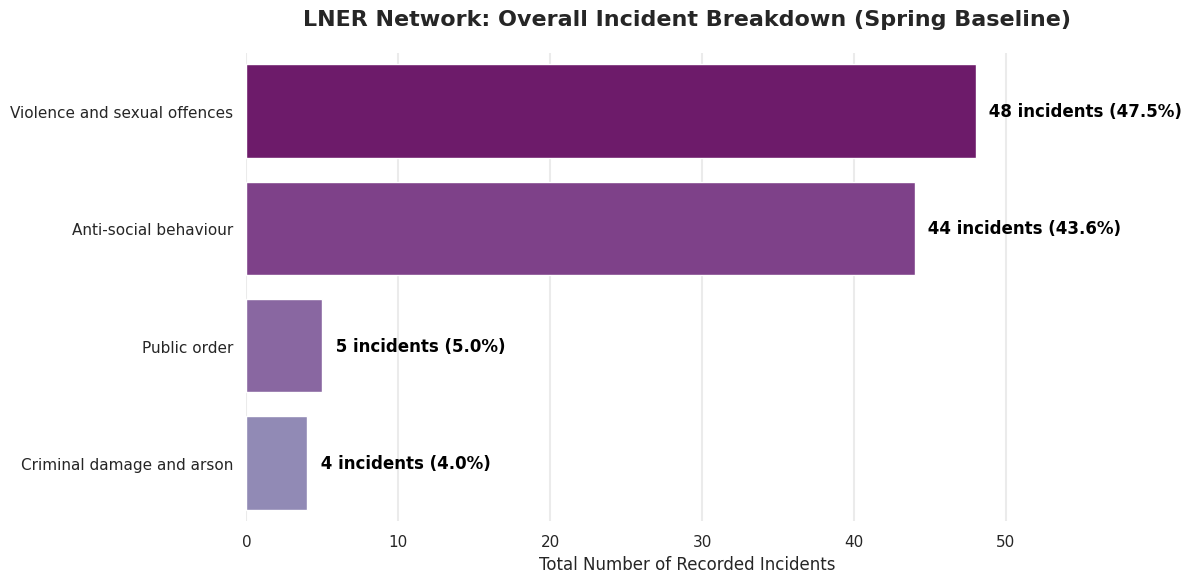

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the master visual theme and an 8-colour palette so the lightest colour remains visible
sns.set_theme(style="whitegrid")
MASTER_PALETTE = sns.color_palette("BuPu_r", 8)

print("Overall Crime Breakdown")

# Count the raw incidents directly from the main dataframe
crime_counts = df_main['Crime type'].value_counts().reset_index()
crime_counts.columns = ['Crime Type', 'Incident Count']

# Calculate percentages for the labels
total_crimes = crime_counts['Incident Count'].sum()
crime_counts['Percentage'] = (crime_counts['Incident Count'] / total_crimes * 100).round(1)

# Generate and save the bar chart
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(x='Incident Count', y='Crime Type', data=crime_counts, palette=MASTER_PALETTE)

for p, index in zip(ax1.patches, crime_counts.index):
    count = crime_counts.loc[index, 'Incident Count']
    pct = crime_counts.loc[index, 'Percentage']
    ax1.annotate(f' {count} incidents ({pct}%)',
                 (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=12, fontweight='bold', color='black')

plt.title('LNER Network: Overall Incident Breakdown (Spring Baseline)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Number of Recorded Incidents', fontsize=12)
plt.ylabel('')
plt.xlim(0, max(crime_counts['Incident Count']) + 10)

# Add light x-axis lines behind the bars
sns.despine(left=True, bottom=True)
ax1.set_axisbelow(True)
ax1.xaxis.grid(True, color='#EBEBEB', linestyle='-', linewidth=1.5)

plt.tight_layout()
plt.savefig('01_Overall_Crime_Breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

**Feature Engineering**

In [18]:
print("Pivoting Crime Data & Merging External Factors")

# Group the raw data by Station and Month to create our training base
pivot_crimes = df_main.pivot_table(
    index=['Station_Code', 'Month', 'MAA_Pct', 'Cancellation_Pct'],
    columns='Crime type',
    aggfunc='size',
    fill_value=0
).reset_index()

# Isolate ASB and create the binary target variable (0 or 1)
pivot_crimes = pivot_crimes.rename(columns={'Anti-social behaviour': 'ASB_Count'})
pivot_crimes['High_Risk_ASB'] = (pivot_crimes['ASB_Count'] > 0).astype(int)

# Merge the external weather and events data based on Station and Month
pivot_crimes = pd.merge(pivot_crimes, df_ext, on=['Station_Code', 'Month'], how='left')

# Fill any missing data gaps to prevent algorithm errors
pivot_crimes['Major_Events_Count'] = pivot_crimes['Major_Events_Count'].fillna(0).astype(int)
pivot_crimes['Avg_Temp_C'] = pivot_crimes['Avg_Temp_C'].fillna(10.0)
pivot_crimes['Avg_Rain_mm'] = pivot_crimes['Avg_Rain_mm'].fillna(0.0).astype(float)
pivot_crimes['Footfall_Rank_GB'] = pivot_crimes['Footfall_Rank_GB'].fillna(100).astype(int)

Pivoting Crime Data & Merging External Factors


/tmp/ipykernel_11603/3881578737.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot_crimes['Major_Events_Count'] = pivot_crimes['Major_Events_Count'].fillna(0).astype(int)
/tmp/ipykernel_11603/3881578737.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot_crimes['Avg_Temp_C'] = pivot_crimes['Avg_Temp_C'].fillna(10.0)
/tmp/ipykernel_11603/3881578737.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the

**Socioeconomic Analysi**

Calculating Pub Density & Crime Links


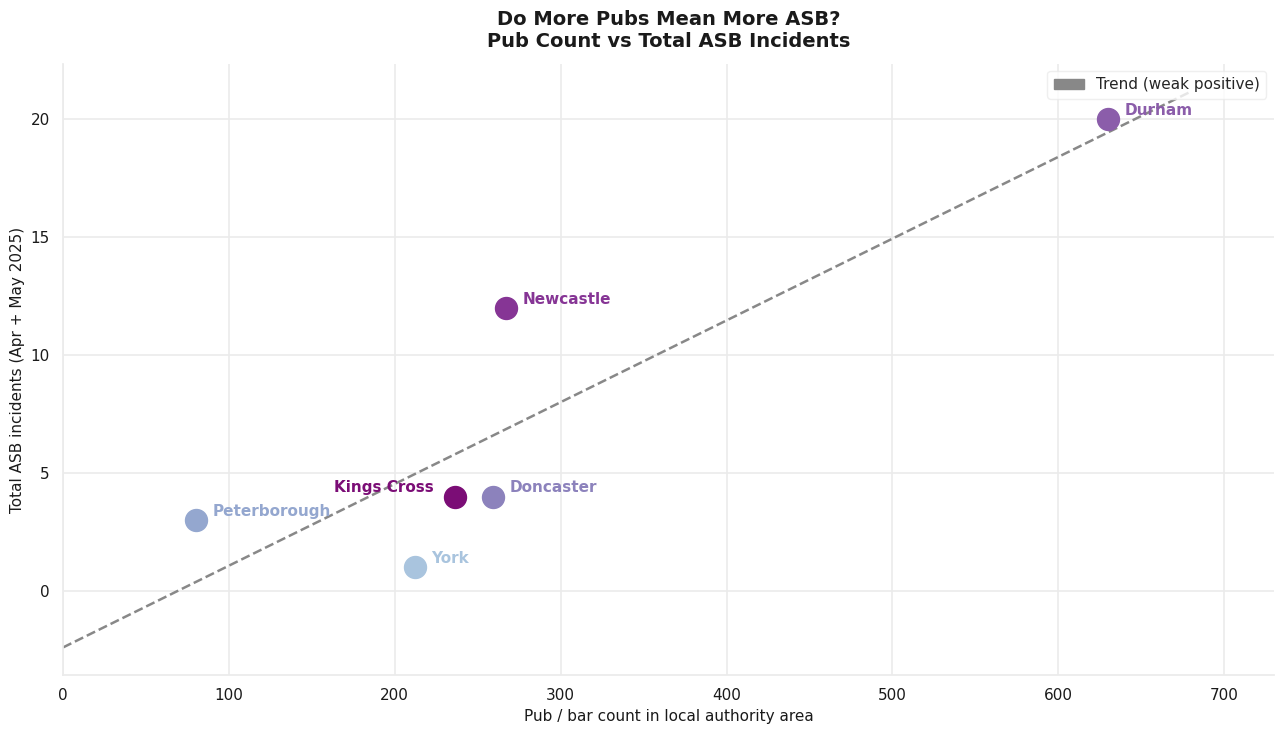

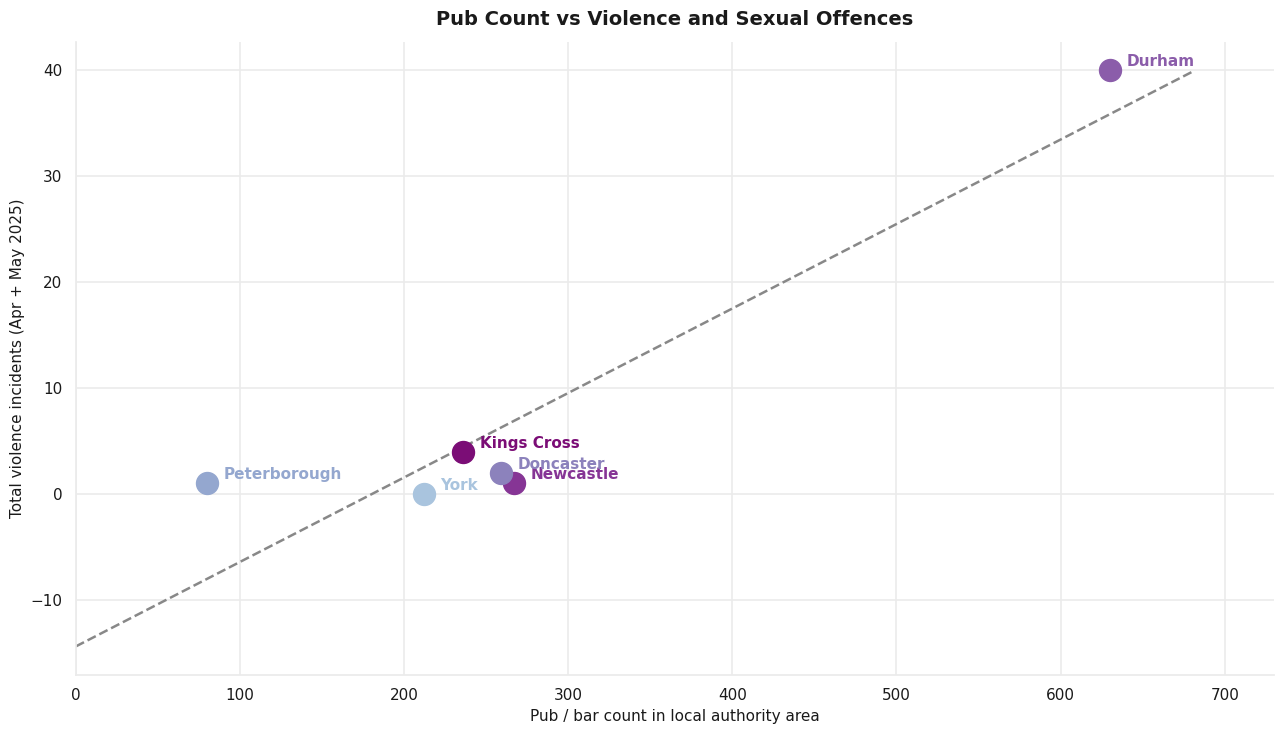

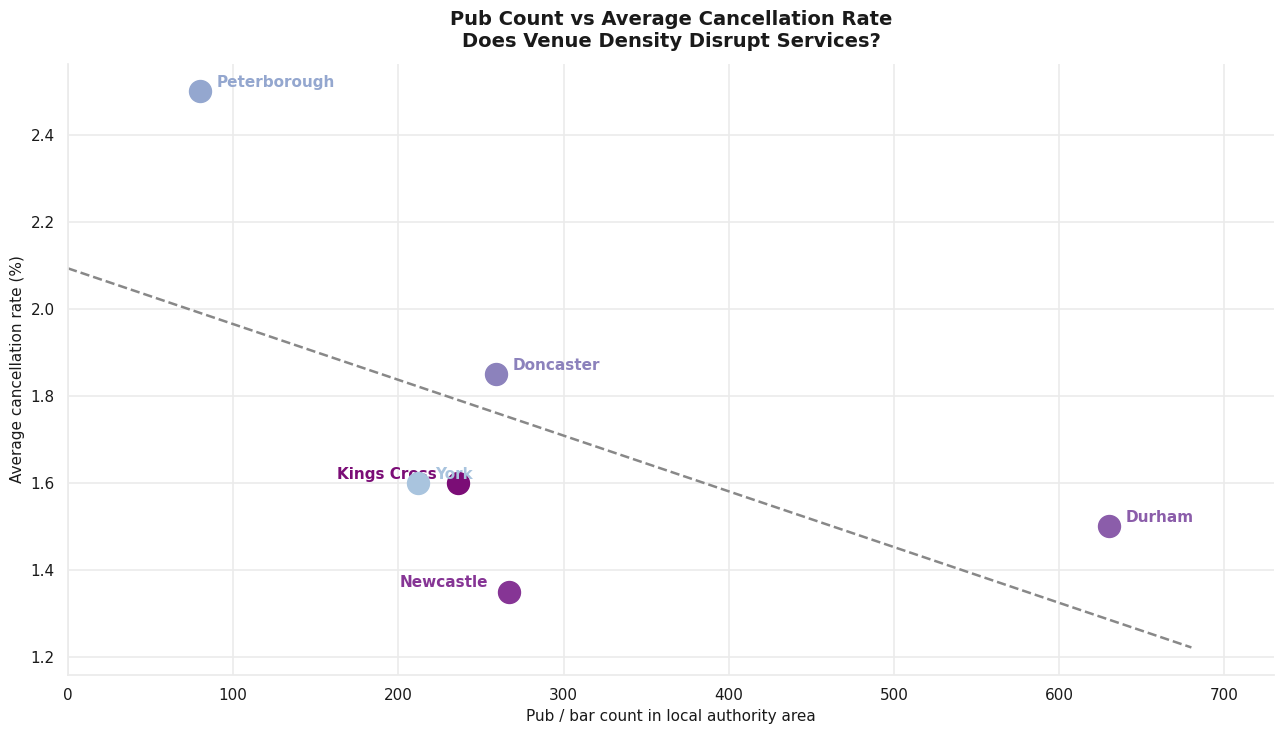

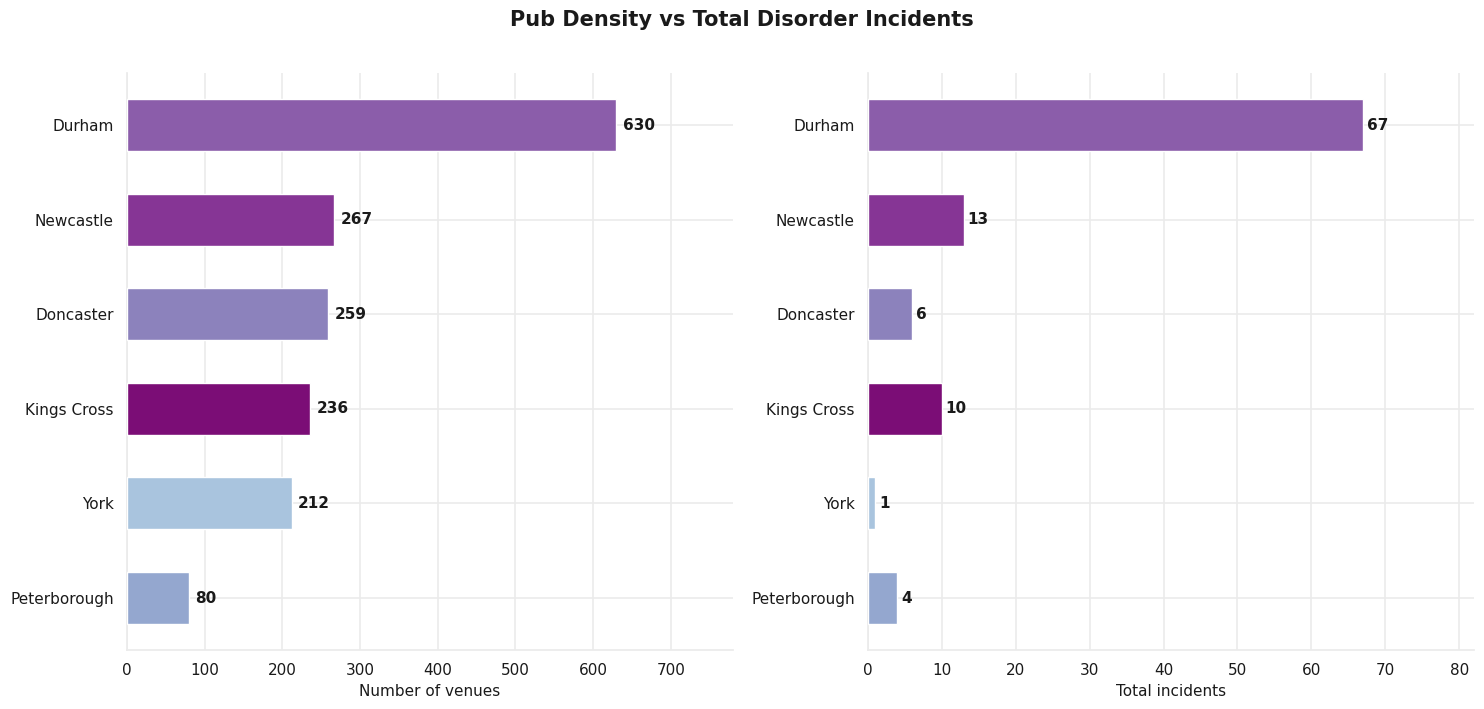

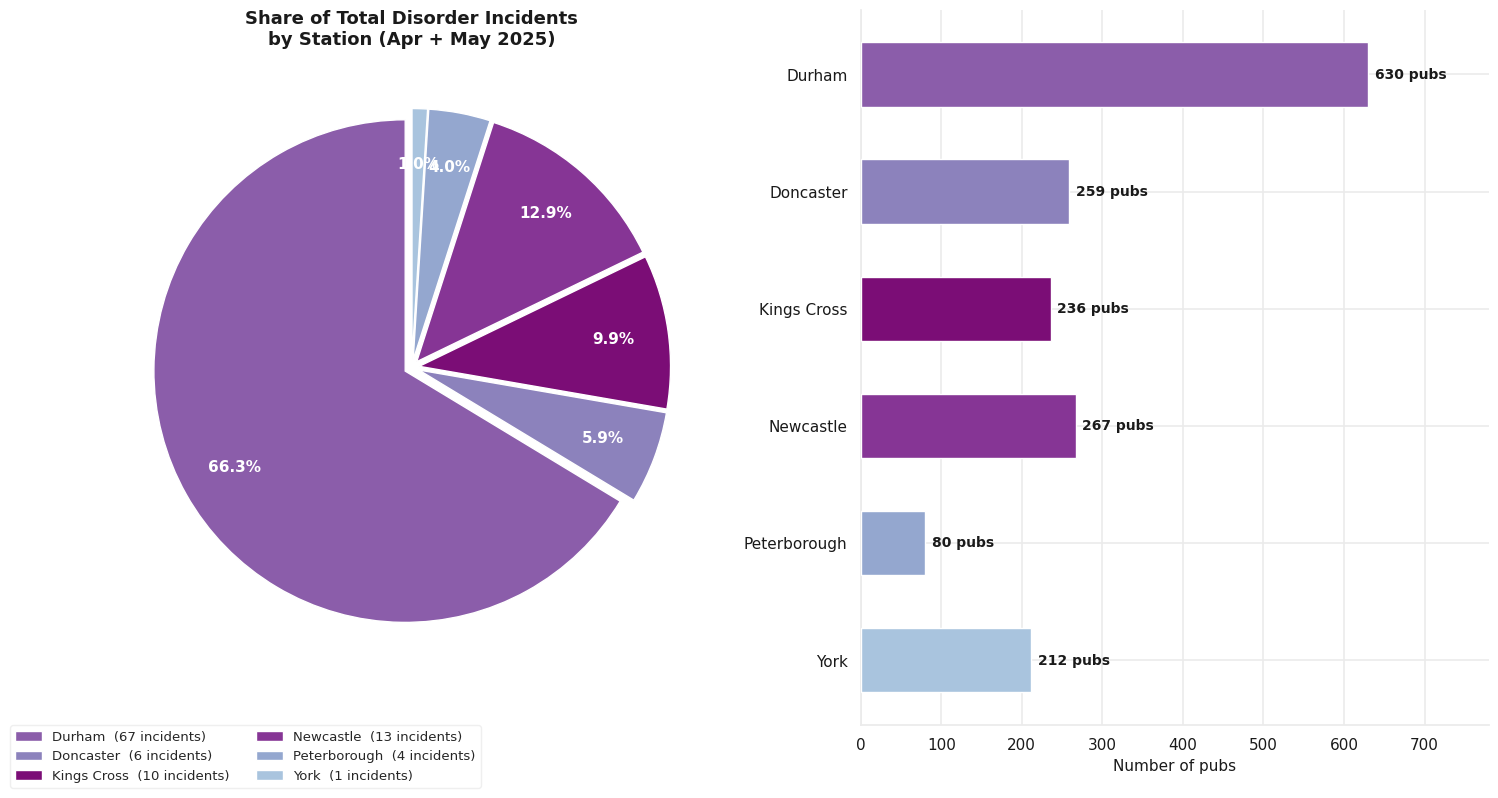

In [19]:
import numpy as np
import matplotlib.patches as mpatches

print("Calculating Pub Density & Crime Links")

# Mappings to link LNER stations to geographic Local Authorities
code_to_name = {'DHM': 'Durham', 'NCL': 'Newcastle', 'KGX': 'Kings Cross', 'DON': 'Doncaster', 'PBO': 'Peterborough', 'YRK': 'York'}
name_to_la = {'Durham': 'Durham', 'Newcastle': 'Newcastle Upon Tyne', 'Kings Cross': 'Camden', 'Doncaster': 'Doncaster', 'Peterborough': 'Peterborough City', 'York': 'York'}
stations = ['Durham', 'Newcastle', 'Kings Cross', 'Doncaster', 'Peterborough', 'York']

# 1. Calculate Pub Counts per Authority dynamically
pubs_only = df_pubs[df_pubs['BusinessType'] == 'Pub/bar/nightclub']
la_pub_counts = pubs_only['LocalAuthorityName'].value_counts().to_dict()
pub_count = {name: la_pub_counts.get(la, 0) for name, la in name_to_la.items()}

# 2. Extract Incident & Cancellation Totals directly from our pivoted data
asb_total = pivot_crimes.groupby('Station_Code')['ASB_Count'].sum().rename(index=code_to_name).to_dict()

# Safely extract violence if it exists in the data
if 'Violence and sexual offences' in pivot_crimes.columns:
    violence_total = pivot_crimes.groupby('Station_Code')['Violence and sexual offences'].sum().rename(index=code_to_name).to_dict()
else:
    violence_total = {name: 0 for name in stations}

cancel_rate = pivot_crimes.groupby('Station_Code')['Cancellation_Pct'].mean().rename(index=code_to_name).to_dict()

# Total Disorder (sum of all available crime types)
known_crimes = ['ASB_Count', 'Violence and sexual offences', 'Public order', 'Criminal damage and arson']
avail_crimes = [c for c in known_crimes if c in pivot_crimes.columns]
disorder_total = pivot_crimes.groupby('Station_Code')[avail_crimes].sum().sum(axis=1).rename(index=code_to_name).to_dict()

# Dynamic Theme & Styling using the 8-colour palette so York is visible
bupu = sns.color_palette("BuPu_r", 8).as_hex()
COLOURS = {'Kings Cross': bupu[0], 'Newcastle': bupu[1], 'Durham': bupu[2], 'Doncaster': bupu[3], 'Peterborough': bupu[4], 'York': bupu[5]}
BG, TEXT, GRID, TREND, ANNOT = 'white', '#1A1A1A', '#EBEBEB', '#888888', '#555555'

def style_ax(ax, title, xlabel, ylabel):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel, color=TEXT, fontsize=11)
    ax.set_ylabel(ylabel, color=TEXT, fontsize=11)
    ax.tick_params(colors=TEXT)
    ax.spines['bottom'].set_color(GRID)
    ax.spines['left'].set_color(GRID)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, color=GRID, linewidth=1.2, linestyle='-')
    ax.set_axisbelow(True)

# CHART 1: Pubs vs ASB
fig, ax = plt.subplots(figsize=(13, 7.5))
xs, ys = [pub_count[s] for s in stations], [asb_total[s] for s in stations]
m, b = np.polyfit(xs, ys, 1)
xline = np.linspace(0, max(xs) + 50, 200)
ax.plot(xline, m*xline+b, '--', color=TREND, linewidth=1.8, label='Trend', zorder=1)

for s in stations:
    x, y = pub_count[s], asb_total[s]
    ax.scatter(x, y, color=COLOURS[s], s=250, zorder=3)
    ax.annotate(s, (x, y), xytext=(12 if s != 'Kings Cross' else -15, 3), textcoords='offset points', color=COLOURS[s], fontsize=11, fontweight='bold', ha='left' if s != 'Kings Cross' else 'right')

ax.set_xlim(0, max(xs) + 100)
style_ax(ax, 'Do More Pubs Mean More ASB?\nPub Count vs Total ASB Incidents', 'Pub / bar count in local authority area', 'Total ASB incidents (Apr + May 2025)')
ax.legend(handles=[mpatches.Patch(color=TREND, label='Trend (weak positive)')], loc='upper right', facecolor='white', edgecolor=GRID)
plt.tight_layout()
plt.savefig('02_Pubs_vs_ASB.png', dpi=150, bbox_inches='tight')
plt.show()

# CHART 2: Pubs vs Violence
fig, ax = plt.subplots(figsize=(13, 7.5))
xs, ys = [pub_count[s] for s in stations], [violence_total[s] for s in stations]
m, b = np.polyfit(xs, ys, 1)
ax.plot(xline, m*xline+b, '--', color=TREND, linewidth=1.8, zorder=1)

for s in stations:
    x, y = pub_count[s], violence_total[s]
    ax.scatter(x, y, color=COLOURS[s], s=250, zorder=3)
    ax.annotate(s, (x, y), xytext=(12, 3), textcoords='offset points', color=COLOURS[s], fontsize=11, fontweight='bold')

ax.set_xlim(0, max(xs) + 100)
style_ax(ax, 'Pub Count vs Violence and Sexual Offences', 'Pub / bar count in local authority area', 'Total violence incidents (Apr + May 2025)')
plt.tight_layout()
plt.savefig('03_Pubs_vs_Violence.png', dpi=150, bbox_inches='tight')
plt.show()

# CHART 3: Pubs vs Cancellations
fig, ax = plt.subplots(figsize=(13, 7.5))
xs, ys = [pub_count[s] for s in stations], [cancel_rate[s] for s in stations]
m, b = np.polyfit(xs, ys, 1)
ax.plot(xline, m*xline+b, '--', color=TREND, linewidth=1.8, zorder=1)

for s in stations:
    x, y = pub_count[s], cancel_rate[s]
    ax.scatter(x, y, color=COLOURS[s], s=250, zorder=3)
    ha, offset_x = ('right', -15) if s in ('Kings Cross','Newcastle') else ('left', 12)
    ax.annotate(s, (x, y), xytext=(offset_x, 3), textcoords='offset points', color=COLOURS[s], fontsize=11, fontweight='bold', ha=ha)

ax.set_xlim(0, max(xs) + 100)
style_ax(ax, 'Pub Count vs Average Cancellation Rate\nDoes Venue Density Disrupt Services?', 'Pub / bar count in local authority area', 'Average cancellation rate (%)')
plt.tight_layout()
plt.savefig('04_Pubs_vs_Cancellations.png', dpi=150, bbox_inches='tight')
plt.show()

# CHART 4: Pub Density vs Disorder Ranking
ranked = sorted(stations, key=lambda s: pub_count[s])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Pub Density vs Total Disorder Incidents', color=TEXT, fontsize=15, fontweight='bold', y=1.01)

colours_ranked = [COLOURS[s] for s in ranked]

# Left: Pub Count
bars1 = ax1.barh(ranked, [pub_count[s] for s in ranked], color=colours_ranked, height=0.55, zorder=3)
ax1.set_title('Pub / Bar Count\n(ranked highest to lowest)', color=TEXT, fontsize=12, fontweight='bold')
for bar, s in zip(bars1, ranked):
    ax1.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2, str(pub_count[s]), va='center', color=TEXT, fontsize=11, fontweight='bold')
ax1.set_xlim(0, max(pub_count.values()) + 150)
style_ax(ax1, '', 'Number of venues', '')

# Right: Disorder
bars2 = ax2.barh(ranked, [disorder_total[s] for s in ranked], color=colours_ranked, height=0.55, zorder=3)
ax2.set_title('Total Disorder Incidents', color=TEXT, fontsize=12, fontweight='bold')
for bar, s in zip(bars2, ranked):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(disorder_total[s]), va='center', color=TEXT, fontsize=11, fontweight='bold')
ax2.set_xlim(0, max(disorder_total.values()) + 15)
style_ax(ax2, '', 'Total incidents', '')

plt.tight_layout()
plt.savefig('05_Pub_vs_Incident_Ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# CHART 5: Pie + Bar Comparison
fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(15, 8))

pie_order = ['Durham','Doncaster','Kings Cross','Newcastle','Peterborough','York']
pie_vals = [disorder_total[s] for s in pie_order]
pie_cols = [COLOURS[s] for s in pie_order]

wedges, texts, autotexts = ax_pie.pie(pie_vals, labels=None, colors=pie_cols, autopct='%1.1f%%', startangle=90, explode=[0.03]*6, pctdistance=0.78, textprops={'color': TEXT})
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')

ax_pie.set_title('Share of Total Disorder Incidents\nby Station (Apr + May 2025)', color=TEXT, fontsize=13, fontweight='bold')
legend_labels = [f"{s}  ({disorder_total[s]} incidents)" for s in pie_order]
ax_pie.legend(wedges, legend_labels, loc='lower left', bbox_to_anchor=(-0.15,-0.18), fontsize=9.5, ncol=2, facecolor='white', edgecolor=GRID)

bar_order = ['York','Peterborough','Newcastle','Kings Cross','Doncaster','Durham']
bars = ax_bar.barh(bar_order, [pub_count[s] for s in bar_order], color=[COLOURS[s] for s in bar_order], height=0.55, zorder=3)
ax_bar.set_title('Pub Count per Station\n(for comparison)', color=TEXT, fontsize=13, fontweight='bold')
for bar, s in zip(bars, bar_order):
    ax_bar.text(bar.get_width()+8, bar.get_y()+bar.get_height()/2, f"{pub_count[s]} pubs", va='center', color=TEXT, fontsize=10, fontweight='bold')
ax_bar.set_xlim(0, max(pub_count.values()) + 150)
style_ax(ax_bar, '', 'Number of pubs', '')

plt.tight_layout()
plt.savefig('06_Incidents_Pie_Chart.png', dpi=150, bbox_inches='tight')
plt.show()

**ASB Predictive Model**

Training ASB Model & Drivers Extraction


/tmp/ipykernel_11603/878651699.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Importance', y='Feature', data=importances_asb.head(7), palette=MASTER_PALETTE)
/tmp/ipykernel_11603/878651699.py:28: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  ax2 = sns.barplot(x='Importance', y='Feature', data=importances_asb.head(7), palette=MASTER_PALETTE)


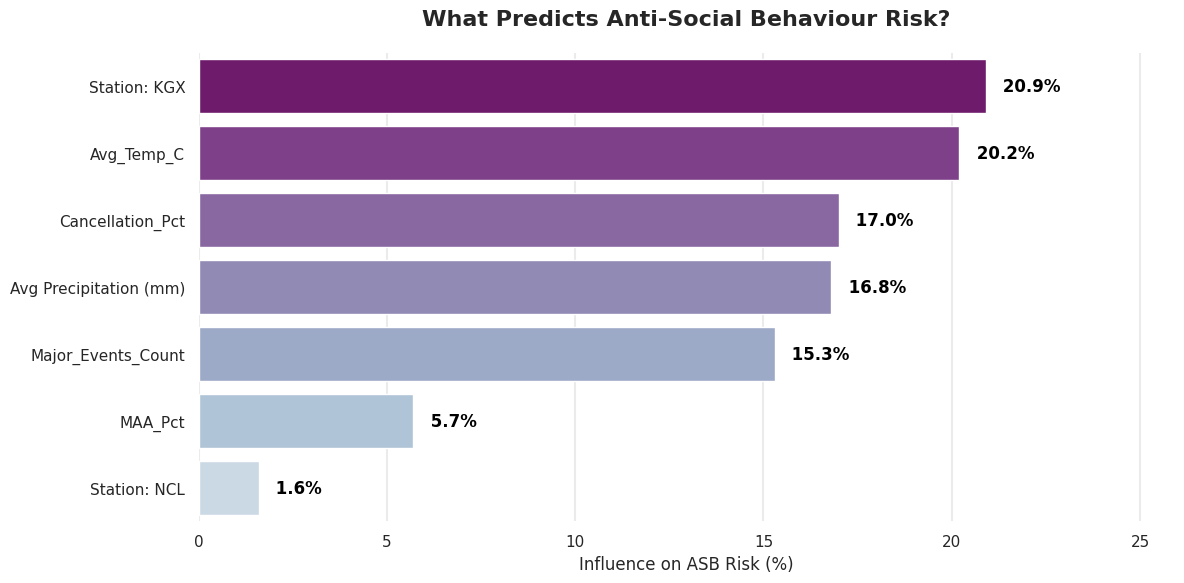

In [20]:
from sklearn.ensemble import RandomForestClassifier

print("Training ASB Model & Drivers Extraction")

# Define the target and features for the ASB model
y_asb = pivot_crimes['High_Risk_ASB']
X_asb = pivot_crimes[['Station_Code', 'MAA_Pct', 'Cancellation_Pct', 'Major_Events_Count', 'Avg_Temp_C', 'Avg_Rain_mm']]

# Convert categorical station codes into mathematical dummy variables
X_asb = pd.get_dummies(X_asb, columns=['Station_Code'])

# Train the Classifier with a set random state for consistent results
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=158)
rf_classifier.fit(X_asb, y_asb)

# Extract importances directly from the trained model
importances_asb = pd.DataFrame({
    'Feature': X_asb.columns,
    'Importance': (rf_classifier.feature_importances_ * 100).round(1)
}).sort_values(by='Importance', ascending=False)

# Clean up the labels for a more professional chart output
importances_asb['Feature'] = importances_asb['Feature'].str.replace('Station_Code_', 'Station: ')
importances_asb['Feature'] = importances_asb['Feature'].str.replace('Avg_Rain_mm', 'Avg Precipitation (mm)')

# Generate and save the ASB Feature Importance chart
plt.figure(figsize=(12, 6))
ax2 = sns.barplot(x='Importance', y='Feature', data=importances_asb.head(7), palette=MASTER_PALETTE)
for p, index in zip(ax2.patches, importances_asb.head(7).index):
    val = importances_asb.loc[index, 'Importance']
    ax2.annotate(f' {val}%',
                 (p.get_width() + 0.3, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=12, fontweight='bold', color='black')

plt.title('What Predicts Anti-Social Behaviour Risk?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Influence on ASB Risk (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, max(importances_asb['Importance']) + 5)

# Add light x-axis lines
sns.despine(left=True, bottom=True)
ax2.set_axisbelow(True)
ax2.xaxis.grid(True, color='#EBEBEB', linestyle='-', linewidth=1.5)

plt.tight_layout()
plt.savefig('07_ASB_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

**Cancellation Drivers Model**

Training Cancellation Model & Drivers Extraction


/tmp/ipykernel_11603/2877559932.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x='Importance', y='Feature', data=importances_canc.head(5), palette=MASTER_PALETTE)
/tmp/ipykernel_11603/2877559932.py:28: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax3 = sns.barplot(x='Importance', y='Feature', data=importances_canc.head(5), palette=MASTER_PALETTE)


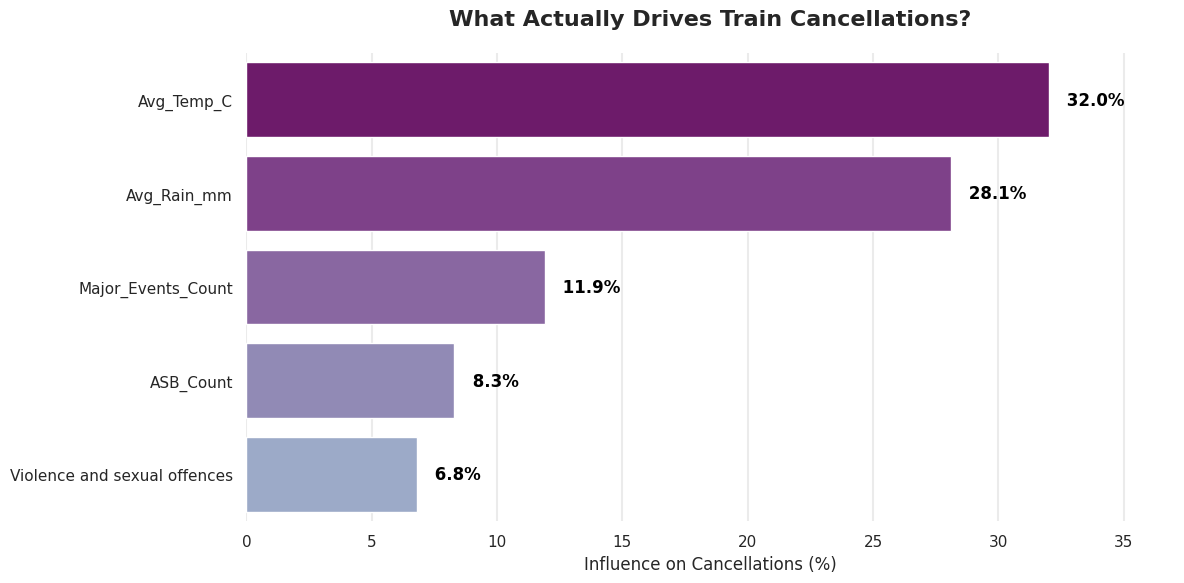

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

print("Training Cancellation Model & Drivers Extraction")

# Define the target and features for the Cancellation model
y_canc = pivot_crimes['Cancellation_Pct']
X_canc = pivot_crimes.drop(columns=['Station_Code', 'Month', 'Cancellation_Pct', 'Footfall_Rank_GB'])

# Convert any remaining categorical text into mathematical formats
X_canc = pd.get_dummies(X_canc)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_canc, y_canc, test_size=0.2, random_state=158)

# Train the Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=158)
rf_regressor.fit(X_train, y_train)

# Extract importances directly from the trained regressor
importances_canc = pd.DataFrame({
    'Feature': X_canc.columns,
    'Importance': (rf_regressor.feature_importances_ * 100).round(1)
}).sort_values(by='Importance', ascending=False)

# Generate and save the Cancellation Drivers chart
plt.figure(figsize=(12, 6))
ax3 = sns.barplot(x='Importance', y='Feature', data=importances_canc.head(5), palette=MASTER_PALETTE)
for p, index in zip(ax3.patches, importances_canc.head(5).index):
    val = importances_canc.loc[index, 'Importance']
    ax3.annotate(f' {val}%',
                 (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=12, fontweight='bold', color='black')

plt.title('What Actually Drives Train Cancellations?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Influence on Cancellations (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, max(importances_canc['Importance']) + 5)

# Add light x-axis lines
sns.despine(left=True, bottom=True)
ax3.set_axisbelow(True)
ax3.xaxis.grid(True, color='#EBEBEB', linestyle='-', linewidth=1.5)

plt.tight_layout()
plt.savefig('08_Cancellation_Drivers.png', dpi=300, bbox_inches='tight')
plt.show()

**Final Executive Dashboard**

Final Operations Dashboard


/tmp/ipykernel_11603/3012234162.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Probability_Raw', y='Station_Label', data=results_df.head(10), palette=MASTER_PALETTE, ax=ax_top)
/tmp/ipykernel_11603/3012234162.py:25: UserWarning: 
The palette list has fewer values (8) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Probability_Raw', y='Station_Label', data=results_df.head(10), palette=MASTER_PALETTE, ax=ax_top)


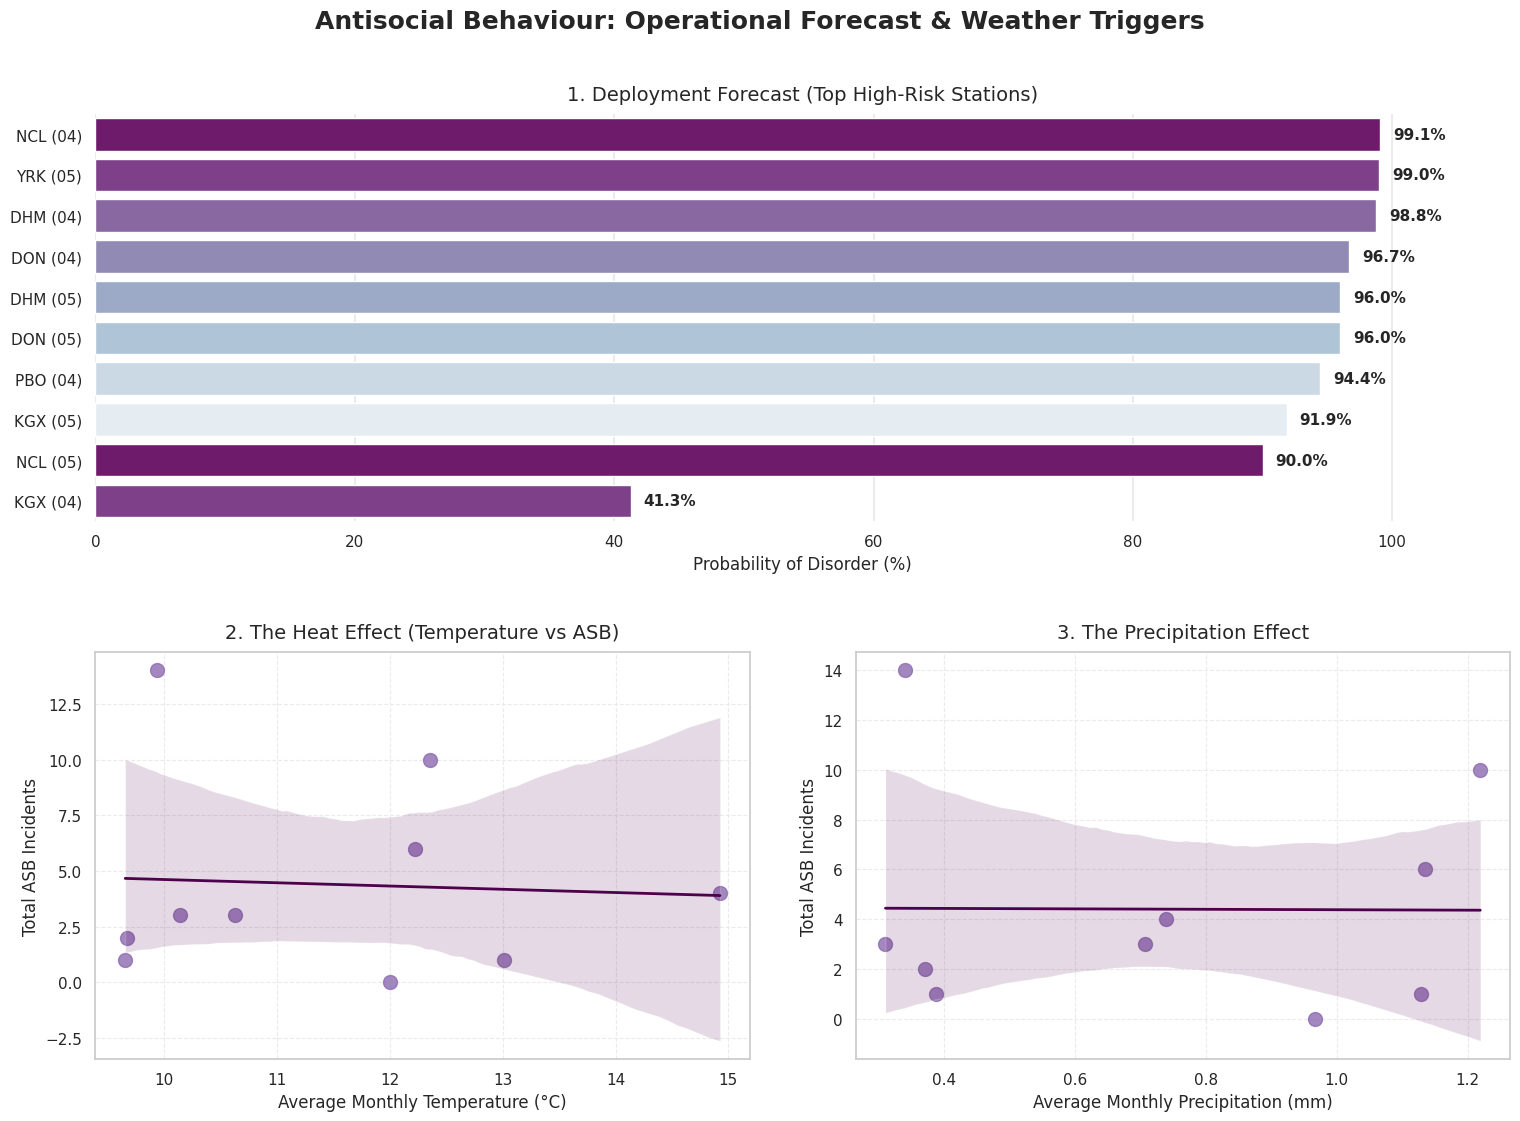

In [22]:
print("Final Operations Dashboard")

# Extract probability percentages from the ASB model
risk_probabilities = rf_classifier.predict_proba(X_asb)[:, 1]

# Create a clean results dataframe for the final deployment table
results_df = pivot_crimes[['Station_Code', 'Month', 'ASB_Count', 'Major_Events_Count', 'Avg_Temp_C', 'Avg_Rain_mm']].copy()
results_df['Probability_Raw'] = risk_probabilities * 100
results_df['Predicted_ASB_Probability'] = results_df['Probability_Raw'].round(1).astype(str) + '%'
results_df['Station_Label'] = results_df['Station_Code'] + " (" + results_df['Month'].str[-2:] + ")"
results_df = results_df.sort_values(by='Probability_Raw', ascending=False)

# Save the final prediction table to CSV
results_df.to_csv("ASB_Risk_Forecast_Final.csv", index=False)

# Set up the 3-panel dashboard layout
fig = plt.figure(figsize=(16, 12))
ax_top = plt.subplot(2, 1, 1)
ax_bot1 = plt.subplot(2, 2, 3)
ax_bot2 = plt.subplot(2, 2, 4)

fig.suptitle('Antisocial Behaviour: Operational Forecast & Weather Triggers', fontsize=18, fontweight='bold', y=0.96)

# Top Panel: Deployment Forecast
sns.barplot(x='Probability_Raw', y='Station_Label', data=results_df.head(10), palette=MASTER_PALETTE, ax=ax_top)
ax_top.set_title('1. Deployment Forecast (Top High-Risk Stations)', fontsize=14, pad=10)
ax_top.set_xlabel('Probability of Disorder (%)')
ax_top.set_ylabel('')
ax_top.set_xlim(0, max(results_df['Probability_Raw']) + 10)
for p in ax_top.patches:
    ax_top.annotate(f'{p.get_width():.1f}%',
                 (p.get_width() + 1.0, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=11, fontweight='bold')

# Add light x-axis lines to the bar chart
sns.despine(ax=ax_top, left=True, bottom=True)
ax_top.set_axisbelow(True)
ax_top.xaxis.grid(True, color='#EBEBEB', linestyle='-', linewidth=1.5)

# Ensure scatter plots match the purple theme
SCATTER_COLOR = '#8c6bb1'

# Bottom Left Panel: Temperature Effect
sns.regplot(x='Avg_Temp_C', y='ASB_Count', data=results_df, ax=ax_bot1,
            scatter_kws={'s': 100, 'color': SCATTER_COLOR, 'alpha': 0.8},
            line_kws={'color': '#4d004b', 'linewidth': 2})
ax_bot1.set_title('2. The Heat Effect (Temperature vs ASB)', fontsize=14, pad=10)
ax_bot1.set_xlabel('Average Monthly Temperature (°C)')
ax_bot1.set_ylabel('Total ASB Incidents')
ax_bot1.grid(True, color='#EBEBEB', linestyle='--', linewidth=0.8)

# Bottom Right Panel: Precipitation Effect
sns.regplot(x='Avg_Rain_mm', y='ASB_Count', data=results_df, ax=ax_bot2,
            scatter_kws={'s': 100, 'color': SCATTER_COLOR, 'alpha': 0.8},
            line_kws={'color': '#4d004b', 'linewidth': 2})
ax_bot2.set_title('3. The Precipitation Effect', fontsize=14, pad=10)
ax_bot2.set_xlabel('Average Monthly Precipitation (mm)')
ax_bot2.set_ylabel('Total ASB Incidents')
ax_bot2.grid(True, color='#EBEBEB', linestyle='--', linewidth=0.8)

plt.tight_layout(pad=3.0)
plt.savefig('09_ASB_Executive_Dashboard_Final.png', dpi=300, bbox_inches='tight')
plt.show()

**Zip and Download**

In [23]:
import zipfile
import os
from google.colab import files

print("Packaging all files into a single ZIP")

# List of all files generated by the script
files_to_zip = [
    '01_Overall_Crime_Breakdown.png',
    '02_Pubs_vs_ASB.png',
    '03_Pubs_vs_Violence.png',
    '04_Pubs_vs_Cancellations.png',
    '05_Pub_vs_Incident_Ranking.png',
    '06_Incidents_Pie_Chart.png',
    '07_ASB_Feature_Importance.png',
    '08_Cancellation_Drivers.png',
    '09_ASB_Executive_Dashboard_Final.png',
    'ASB_Risk_Forecast_Final.csv'
]

zip_name = 'LNER_Complete_Final_Outputs.zip'

# Create the ZIP archive
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

# Trigger the download in Colab
files.download(zip_name)
print("Downloading.")

Packaging all files into a single ZIP


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading.
